# Stories

## Deskriptive Statistik

#### Setup

In [1]:
import pandas as pd

df = pd.read_csv('../data/2024-07-03-Faces-in-Posts-unfiltered.csv')

In [2]:
df = df.groupby('filename').agg({
    'Ground Truth': lambda x: ', '.join(set(x)),
    'Model': lambda x: ', '.join(set(x)),
    'account_name': 'first',
    'match_score': 'first'
    }).reset_index()

df.rename(columns={'Model': 'FaceNet', 'match_score': 'FaceNet Score'}, inplace=True)

In [3]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131


In [4]:
filtered_df = pd.read_csv('../data/2024-09-09-Filtered-Posts-Front-Runners.csv')

In [5]:
filtered_df.head()

,image,shortcode,username
0,armin_laschet/2021-09-22_14-55-06_UTC_2.jpg,CUIMVtAIcv0,armin_laschet
1,armin_laschet/2021-09-18_19-12-07_UTC_5.jpg,CT-Wks4orcn,armin_laschet
2,armin_laschet/2021-09-15_12-38-48_UTC.jpg,CT17LV3ohf5,armin_laschet
3,armin_laschet/2021-09-21_11-03-21_UTC_1.jpg,CUFNBhQIo6x,armin_laschet
4,armin_laschet/2021-09-23_13-50-48_UTC_1.jpg,CUKpxsNIuW2,armin_laschet


In [6]:
df = df[df['filename'].isin(filtered_df['image'])]

In [7]:
df = pd.merge(df, filtered_df[['image', 'shortcode']], left_on="filename", right_on="image", how="left")

In [8]:
def extract_candidate(row):
  names = row['Ground Truth'].split(', ')
  for name in names:
    if name != "Unknown":
      return name
  return "Unknown"

df['Candidate'] = df.apply(extract_candidate, axis=1)

In [9]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,Annalena Baerbock
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,CTxhb8gMLqn,Annalena Baerbock
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,CTxhb8gMLqn,Annalena Baerbock
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,CTxhb8gMLqn,Annalena Baerbock
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,CTxhb8gMLqn,Annalena Baerbock


In [10]:
count_stories = pd.read_csv('../data/2024-07-09-Post-Count-Annotation-Not-Sampled-GPT4o-V3.csv')

In [11]:
count_stories.head()

,Unnamed: 0,GPT Count,GPT Crowd,Image
0,0,1,False,abaerbock/2021-09-13_14-02-02_UTC.jpg
1,1,2,False,abaerbock/2021-09-13_19-36-55_UTC_1.jpg
2,2,1,False,abaerbock/2021-09-13_19-36-55_UTC_2.jpg
3,3,2,False,abaerbock/2021-09-13_19-36-55_UTC_3.jpg
4,4,1,True,abaerbock/2021-09-13_19-36-55_UTC_4.jpg


In [12]:
count_stories.rename(columns={"Image": "filename"}, inplace=True)

In [13]:
df = pd.merge(df, count_stories[['GPT Count', 'filename']], on="filename", how="left")

In [14]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,Annalena Baerbock,1
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,CTxhb8gMLqn,Annalena Baerbock,2
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,CTxhb8gMLqn,Annalena Baerbock,1
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Unknown, Annalena Baerbock",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,CTxhb8gMLqn,Annalena Baerbock,2
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.540131,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,CTxhb8gMLqn,Annalena Baerbock,1


In [15]:
df['Candidate'] = df['Candidate'].str.replace('Unknown', 'None')

In [16]:
# Merge wide_df mit metadaten.
metadata_df = pd.read_csv('../data/2023-11-02-story-metadata.csv')

In [17]:
users_df = pd.read_csv("../data/2022-10-10-users.csv", sep=";")

In [18]:
users_df = users_df.rename(columns={'id': 'user_id'})

In [19]:
faces_master_df = pd.merge(df[['filename', 'Candidate', 'account_name', 'GPT Count', 'shortcode']], users_df, left_on="account_name", right_on="username", how="left")

In [20]:
len(faces_master_df)

708

In [21]:
faces_master_df.rename(columns={'Candidate': 'Names'}, inplace=True)

In [22]:
faces_master_df.head()

,filename,Names,account_name,GPT Count,shortcode,username,user_id,party,type
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,abaerbock,1,CTw3GFIjJ9z,abaerbock,7012133944,B90DieGruenen,Person
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person


In [23]:
faces_master_df['username'].unique()

array(['abaerbock', 'armin_laschet', 'cdu', 'christianlindner',
       'christlichsozialeunion', 'die_gruenen', 'fdp', 'markus.soeder',
       'olafscholz', 'spdde'], dtype=object)

In [24]:
########### HIER WEITERMACHEN!!!
##### HIER Muss ich am besten GPT Count NaN setzen, dann sollte der Code klappen

import numpy as np

# Function to check if a set contains the string 'None'
def contains_none_string(row):
    # Check if 'None' is in the set
    if 'None' in row['Names']:
      return np.NaN
    else:
      return row['GPT Count']

# Apply the function to each element in the column
faces_master_df['GPT Count'] = faces_master_df.apply(contains_none_string, axis=1)

In [25]:
final_count_df = faces_master_df.copy()
final_count_df.head()

,filename,Names,account_name,GPT Count,shortcode,username,user_id,party,type
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,abaerbock,1,CTw3GFIjJ9z,abaerbock,7012133944,B90DieGruenen,Person
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person


In [26]:
print(final_count_df.head().to_markdown())

|    | filename                                | Names             | account_name   |   GPT Count | shortcode   | username   |    user_id | party         | type   |
|---:|:----------------------------------------|:------------------|:---------------|------------:|:------------|:-----------|-----------:|:--------------|:-------|
|  0 | abaerbock/2021-09-13_14-02-02_UTC.jpg   | Annalena Baerbock | abaerbock      |           1 | CTw3GFIjJ9z | abaerbock  | 7012133944 | B90DieGruenen | Person |
|  1 | abaerbock/2021-09-13_19-36-55_UTC_1.jpg | Annalena Baerbock | abaerbock      |           2 | CTxhb8gMLqn | abaerbock  | 7012133944 | B90DieGruenen | Person |
|  2 | abaerbock/2021-09-13_19-36-55_UTC_2.jpg | Annalena Baerbock | abaerbock      |           1 | CTxhb8gMLqn | abaerbock  | 7012133944 | B90DieGruenen | Person |
|  3 | abaerbock/2021-09-13_19-36-55_UTC_3.jpg | Annalena Baerbock | abaerbock      |           2 | CTxhb8gMLqn | abaerbock  | 7012133944 | B90DieGruenen | Person |
|  4 | aba

### Kandidaten

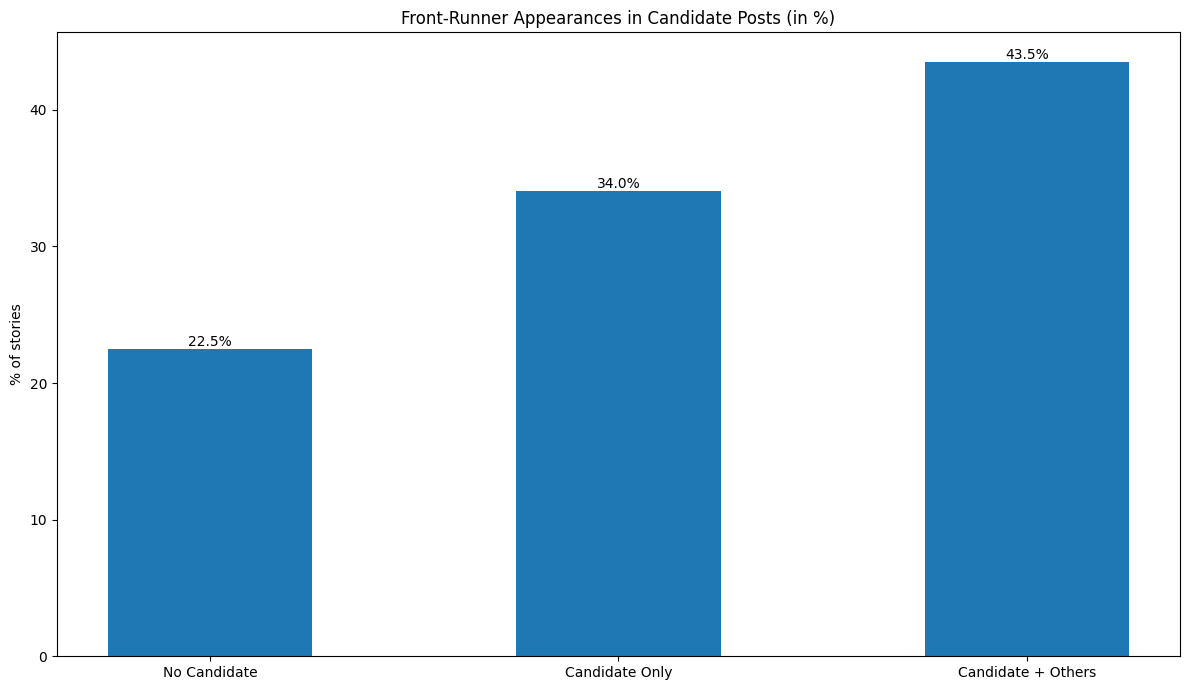

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Calculate counts based on conditions
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }

    # Calculate percentages
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}

    return percentages_dict

# Example DataFrame (replace final_count_df with your actual DataFrame)
# final_count_df = pd.read_csv('path_to_your_data.csv')

# Get percentages for 'Person' type
percentages_dict = get_lengths_and_labels(final_count_df, "Person")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.5
positions = range(len(percentages_dict))

# Plotting the bars
bars = ax.bar(positions, percentages_dict.values(), bar_width)

# Add percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Candidate Posts (in %)')
ax.set_xticks(positions)
ax.set_xticklabels(percentages_dict.keys())

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

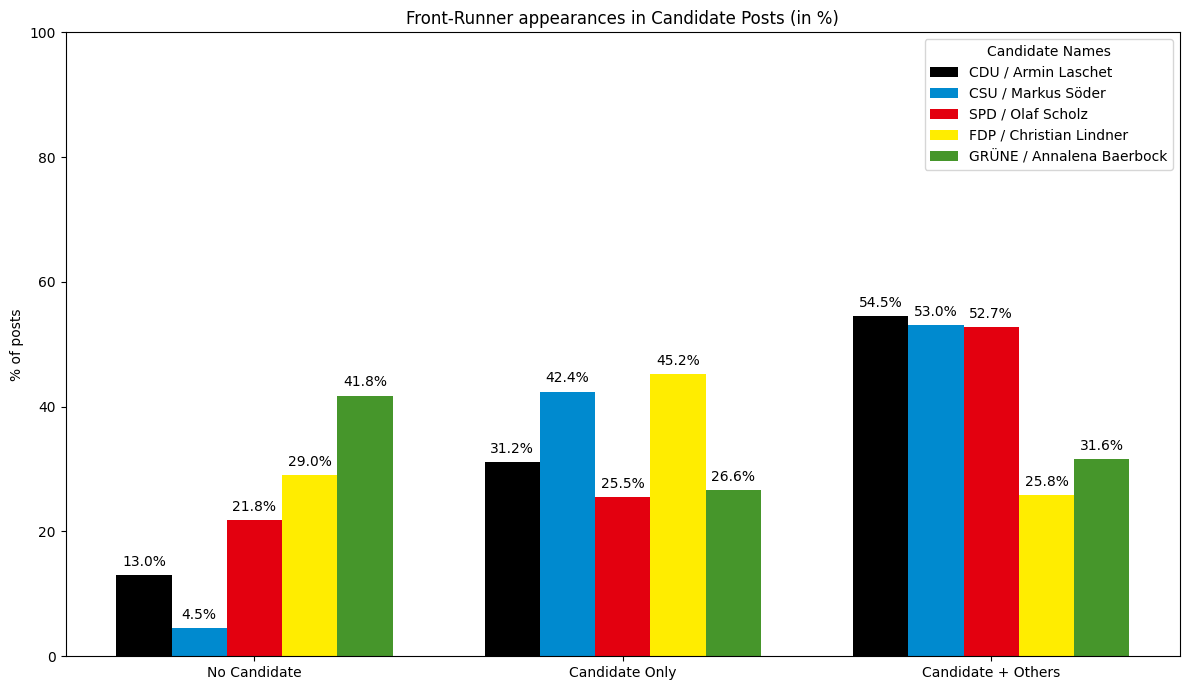

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Static dictionary for candidate-to-party mapping
party_affiliation_names = {
    "CDU": ["CDU / Armin Laschet"],
    "CSU": ["CSU / Markus Söder"],
    "SPD": ["SPD / Olaf Scholz"],
    "FDP": ["FDP / Christian Lindner"],
    "B90DieGruenen": ["GRÜNE / Annalena Baerbock"],
}

# Typical party colors
party_colors = {
    "CDU": "#000000",
    "CSU": "#008ACF",
    "SPD": "#E3000F",
    "FDP": "#FFED00",
    "B90DieGruenen": "#46962B",
}

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Define the conditions
    def apply_conditions(df):
        return {
            'No Candidate': len(df[(df['Names'] == "None")]),
            'Candidate Only': len(df[(df['Names'] != "None") & (df['GPT Count'] == "1")]),
            'Candidate + Others': len(df[(df['Names'] != "None") & (df['GPT Count'] != "0") & (df['GPT Count'] != "1")])
        }

    percentages_dict = {label: [] for label in ['No Candidate', 'Candidate Only', 'Candidate + Others']}
    parties = list(party_affiliation_names.keys())

    # Iterate over each party and apply conditions
    for party in parties:
        party_df = df_filtered[df_filtered['party'] == party]
        total_count = len(party_df)  # Total rows for this party

        # Apply conditions directly to the filtered party_df
        condition_counts = apply_conditions(party_df)

        for label, count in condition_counts.items():
            percentage = (count / total_count) * 100 if total_count > 0 else 0
            percentages_dict[label].append(percentage)

    return percentages_dict, parties

# Get percentages and parties
percentages_dict, parties = get_lengths_and_labels(final_count_df, "Person")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.15
positions = range(len(percentages_dict.keys()))

# Plot bars for each party
for i, party in enumerate(parties):
    candidate_name = party_affiliation_names[party][0]  # Assume one candidate per party for simplicity
    percentages = [percentages_dict[label][i] for label in percentages_dict.keys()]
    ax.bar([p + i * bar_width for p in positions], percentages, bar_width, label=candidate_name, color=party_colors[party])

# Set labels and title
ax.set_ylabel('% of posts')
#ax.set_ylabel('Percentage of Rows')
ax.set_title('Front-Runner appearances in Candidate Posts (in %)')
ax.set_xticks([p + bar_width * (len(parties) - 1) / 2 for p in positions])  # Center x-tick labels
ax.set_xticklabels(percentages_dict.keys())
ax.legend(title='Candidate Names')

# Force y-axis to range from 0 to 100
ax.set_ylim(0, 100)

# Adding labels on top of bars
for i, party in enumerate(parties):
    for j, label in enumerate(percentages_dict.keys()):
        percentage = percentages_dict[label][i]
        ax.text(j + i * bar_width, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

In [29]:
# Create a DataFrame for the table
table_data = {label: percentages_dict[label] for label in percentages_dict}
table_data['Party'] = parties
table_df = pd.DataFrame(table_data)

# Display the table
print(table_df.to_markdown())

|    |   No Candidate |   Candidate Only |   Candidate + Others | Party         |
|---:|---------------:|-----------------:|---------------------:|:--------------|
|  0 |       12.987   |          31.1688 |              54.5455 | CDU           |
|  1 |        4.54545 |          42.4242 |              53.0303 | CSU           |
|  2 |       21.8182  |          25.4545 |              52.7273 | SPD           |
|  3 |       29.0323  |          45.1613 |              25.8065 | FDP           |
|  4 |       41.7722  |          26.5823 |              31.6456 | B90DieGruenen |


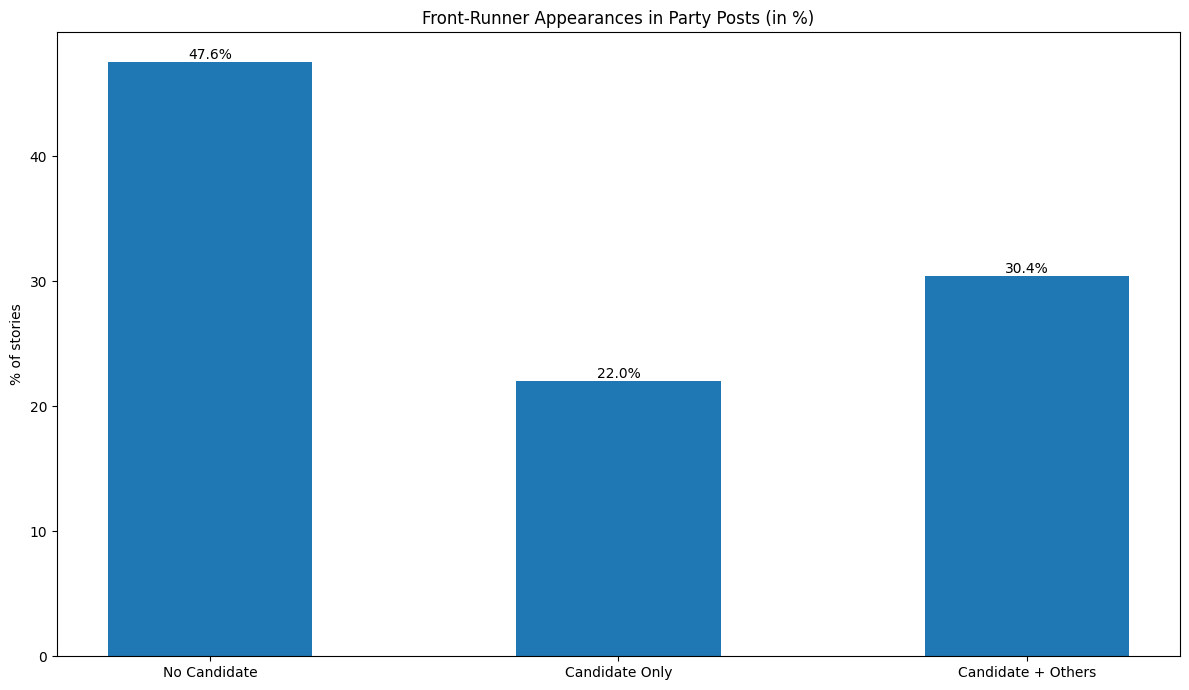

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Calculate counts based on conditions
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }

    # Calculate percentages
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}

    return percentages_dict


# Get percentages for 'Person' type
percentages_dict = get_lengths_and_labels(final_count_df, "Party")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.5
positions = range(len(percentages_dict))

# Plotting the bars
bars = ax.bar(positions, percentages_dict.values(), bar_width)

# Add percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Party Posts (in %)')
ax.set_xticks(positions)
ax.set_xticklabels(percentages_dict.keys())

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

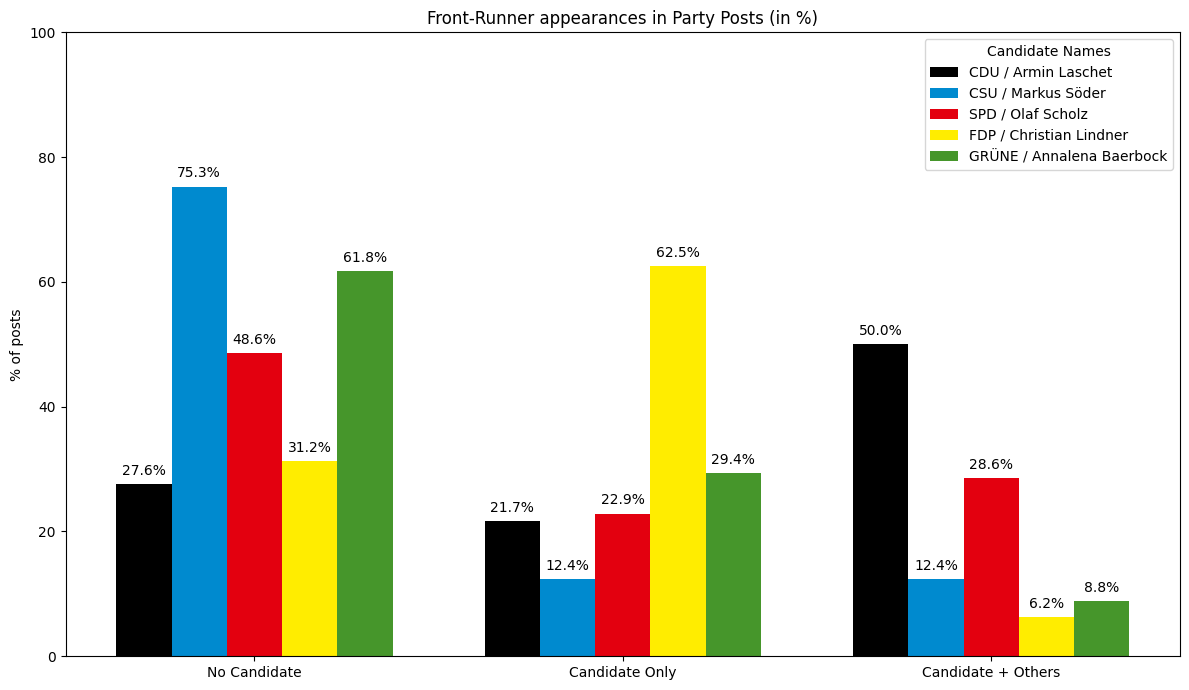

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Static dictionary for candidate-to-party mapping
party_affiliation_names = {
    "CDU": ["CDU / Armin Laschet"],
    "CSU": ["CSU / Markus Söder"],
    "SPD": ["SPD / Olaf Scholz"],
    "FDP": ["FDP / Christian Lindner"],
    "B90DieGruenen": ["GRÜNE / Annalena Baerbock"],
}


# Typical party colors
party_colors = {
    "CDU": "#000000",
    "CSU": "#008ACF",
    "SPD": "#E3000F",
    "FDP": "#FFED00",
    "B90DieGruenen": "#46962B",
}

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Define the conditions
    def apply_conditions(df):
        return {
            'No Candidate': len(df[(df['Names'] == "None")]),
            'Candidate Only': len(df[(df['Names'] != "None") & (df['GPT Count'] == "1")]),
            'Candidate + Others': len(df[(df['Names'] != "None") & (df['GPT Count'] != "0") & (df['GPT Count'] != "1")])
        }

    percentages_dict = {label: [] for label in ['No Candidate', 'Candidate Only', 'Candidate + Others']}
    parties = list(party_affiliation_names.keys())

    # Iterate over each party and apply conditions
    for party in parties:
        party_df = df_filtered[df_filtered['party'] == party]
        total_count = len(party_df)  # Total rows for this party

        # Apply conditions directly to the filtered party_df
        condition_counts = apply_conditions(party_df)

        for label, count in condition_counts.items():
            percentage = (count / total_count) * 100 if total_count > 0 else 0
            percentages_dict[label].append(percentage)

    return percentages_dict, parties

# Get percentages and parties
percentages_dict, parties = get_lengths_and_labels(final_count_df, "Party")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.15
positions = range(len(percentages_dict.keys()))

# Plot bars for each party
for i, party in enumerate(parties):
    candidate_name = party_affiliation_names[party][0]  # Assume one candidate per party for simplicity
    percentages = [percentages_dict[label][i] for label in percentages_dict.keys()]
    ax.bar([p + i * bar_width for p in positions], percentages, bar_width, label=candidate_name, color=party_colors[party])

# Set labels and title
ax.set_ylabel('% of posts')
#ax.set_ylabel('Percentage of Rows')
ax.set_title('Front-Runner appearances in Party Posts (in %)')
ax.set_xticks([p + bar_width * (len(parties) - 1) / 2 for p in positions])  # Center x-tick labels
ax.set_xticklabels(percentages_dict.keys())
ax.legend(title='Candidate Names')

# Force y-axis to range from 0 to 100
ax.set_ylim(0, 100)

# Adding labels on top of bars
for i, party in enumerate(parties):
    for j, label in enumerate(percentages_dict.keys()):
        percentage = percentages_dict[label][i]
        ax.text(j + i * bar_width, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

In [32]:
# Create a DataFrame for the table
table_data = {label: percentages_dict[label] for label in percentages_dict}
table_data['Party'] = parties
table_df = pd.DataFrame(table_data)

# Display the table
print(table_df.to_markdown())

|    |   No Candidate |   Candidate Only |   Candidate + Others | Party         |
|---:|---------------:|-----------------:|---------------------:|:--------------|
|  0 |        27.6316 |          21.7105 |             50       | CDU           |
|  1 |        75.2577 |          12.3711 |             12.3711  | CSU           |
|  2 |        48.5714 |          22.8571 |             28.5714  | SPD           |
|  3 |        31.25   |          62.5    |              6.25    | FDP           |
|  4 |        61.7647 |          29.4118 |              8.82353 | B90DieGruenen |


## Statistische Auswertung

### Unterschiede

### RQ2a: Front Runner vs Party

Across all parties.

Chi-squared: 48.488262881083564, p-value: 2.9573824876169064e-11, Cramér's V: 0.262
Significance level: ***


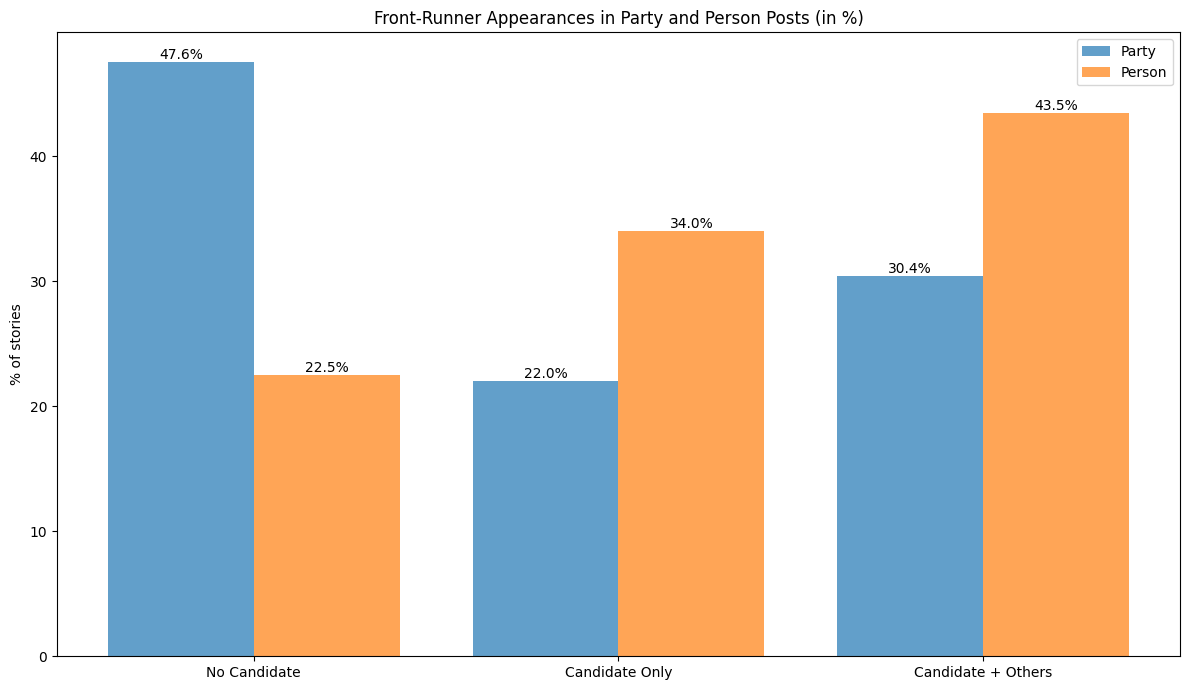

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    df_filtered = df[df['type'] == entity_type]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Get counts for 'Party' type
party_counts, party_percentages = get_lengths_and_labels(final_count_df, "Party")
# Get counts for 'Person' type
person_counts, person_percentages = get_lengths_and_labels(final_count_df, "Person")

# Create contingency table
contingency_table = pd.DataFrame({
    'No Candidate': [party_counts['No Candidate'], person_counts['No Candidate']],
    'Candidate Only': [party_counts['Candidate Only'], person_counts['Candidate Only']],
    'Candidate + Others': [party_counts['Candidate + Others'], person_counts['Candidate + Others']]
}, index=['Party', 'Person'])

# Perform Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramér's V
n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

# Print the results
print(f"Chi-squared: {chi2}, p-value: {p}, Cramér's V: {cramers_v:.3f}")

# Determine significance level
if p < 0.001:
    significance = "***"
elif p < 0.01:
    significance = "**"
elif p < 0.05:
    significance = "*"
else:
    significance = "ns"  # not significant

print(f"Significance level: {significance}")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))
positions = range(len(party_percentages))

# Plotting the bars for Party
bars_party = ax.bar(positions, party_percentages.values(), width=0.4, label='Party', alpha=0.7)
# Plotting the bars for Person with offset
bars_person = ax.bar([p + 0.4 for p in positions], person_percentages.values(), width=0.4, label='Person', alpha=0.7)

# Add percentage labels on top of the bars
for bar in bars_party + bars_person:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Party and Person Posts (in %)')
ax.set_xticks([p + 0.2 for p in positions])
ax.set_xticklabels(party_percentages.keys())
ax.legend()

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()


In [36]:
contingency_table

,No Candidate,Candidate Only,Candidate + Others
Party,175,81,112
Person,76,115,147


### RQ2a: Front Runner vs Party per Party
*UPDATED*: Between Parties


For each party within each account type (Party accounts and Person accounts), the hypotheses tested are:

Null Hypothesis (H₀):
Statement: The distribution of Instagram campaign strategies used by this party is the same as the overall distribution of strategies across all parties within the same account type.

Alternative Hypothesis (H₁):
Statement: The distribution of Instagram campaign strategies used by this party is different from the overall distribution of strategies across all parties within the same account type.

In [37]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
from statsmodels.stats.multitest import multipletests

# Function to calculate counts for each category per party
def get_party_counts(df, party):
    df_filtered = df[df['party'] == party]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    return counts

# Function to perform Chi-squared tests for a given dataframe
def perform_chi_squared_tests(df, group_name):
    # Unique parties in the dataset
    parties = df['party'].unique()

    # Create a contingency table
    contingency_table = pd.DataFrame(index=parties, columns=['No Candidate', 'Candidate Only', 'Candidate + Others']).fillna(0)

    # Fill the contingency table with counts
    for party in parties:
        counts = get_party_counts(df, party)
        contingency_table.loc[party] = [counts['No Candidate'], counts['Candidate Only'], counts['Candidate + Others']]

    # Calculate the total counts for each category across all parties
    overall_counts = contingency_table.sum(axis=0)

    # Initialize results storage
    chi2_results_list = []
    p_values = []  # List to store p-values for multiple testing correction

    # Loop through each party and perform Chi-squared test against overall counts
    for party in parties:
        # Prepare the observed counts for the current party
        observed = contingency_table.loc[party].astype(int).values
        expected = overall_counts.values.astype(float) * (observed.sum() / overall_counts.sum())

        # Perform Chi-squared test
        chi2, p, dof, expected_freqs = chi2_contingency([observed, expected])
        p_values.append(p)  # Store the raw p-value

        # Check if chi-squared test requirements are met
        meets_requirements = np.all(expected_freqs >= 5)

        # Calculate Cramér's V
        n = observed.sum()  # Total number of observations for the party
        r, k = 2, len(observed)  # Rows and columns in the contingency table
        cramers_v = np.sqrt(chi2 / (n * (min(k - 1, r - 1) or 1)))

        # Store initial results without significance label
        chi2_results_list.append({
            'Party': party,
            'Chi-squared': chi2,
            'Raw p-value': p,
            'Cramér\'s V': cramers_v,
            'Meets Chi-squared Requirements': "Yes" if meets_requirements else "No"
        })

    # Apply Bonferroni correction to p-values
    p_values = np.array(p_values)
    corrected_p_values = multipletests(p_values, method='bonferroni')[1]

    # Update results with corrected p-values and significance labels
    for i, result in enumerate(chi2_results_list):
        corrected_p = corrected_p_values[i]
        result['Corrected p-value'] = corrected_p

        # Determine significance level after correction
        if corrected_p < 0.001:
            significance_label = "***"
        elif corrected_p < 0.01:
            significance_label = "**"
        elif corrected_p < 0.05:
            significance_label = "*"
        else:
            significance_label = "ns"
        result['Significant'] = significance_label

    # Convert the results list to a DataFrame
    chi2_results_df = pd.DataFrame(chi2_results_list)

    return chi2_results_df, contingency_table

# Assuming 'account_type' is the column indicating 'Party' or 'Person' accounts
# Split the dataset into Party accounts and Person accounts
df_party_accounts = final_count_df[final_count_df['type'] == 'Party']
df_person_accounts = final_count_df[final_count_df['type'] == 'Person']

# Perform the analysis for Party accounts
chi2_results_party, contingency_table_party = perform_chi_squared_tests(df_party_accounts, "Party")

# Perform the analysis for Person accounts
chi2_results_person, contingency_table_person = perform_chi_squared_tests(df_person_accounts, "Person")


<ipython-input-37-886bd35c1e36>:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  contingency_table = pd.DataFrame(index=parties, columns=['No Candidate', 'Candidate Only', 'Candidate + Others']).fillna(0)
<ipython-input-37-886bd35c1e36>:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  contingency_table = pd.DataFrame(index=parties, columns=['No Candidate', 'Candidate Only', 'Candidate + Others']).fillna(0)


In [38]:
print(chi2_results_party.to_markdown())

|    | Party         |   Chi-squared |   Raw p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|--------------:|--------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | CDU           |    15.2087    |   0.000498289 |    0.317364  | Yes                              |          0.00249145 | **            |
|  1 | CSU           |    16.0773    |   0.000322737 |    0.407119  | Yes                              |          0.00161369 | **            |
|  2 | B90DieGruenen |     5.0351    |   0.0806571   |    0.384826  | Yes                              |          0.403286   | ns            |
|  3 | FDP           |     6.19451   |   0.045173    |    0.622219  | No                               |          0.225865   | ns            |
|  4 | SPD           |     0.0598963 |   0.970496    |    0.0292517 | Yes                              |          1          | ns            |

In [39]:
print(chi2_results_person.to_markdown())

|    | Party         |   Chi-squared |   Raw p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|--------------:|--------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | B90DieGruenen |       6.77044 |     0.0338702 |     0.292749 | Yes                              |           0.169351  | ns            |
|  1 | CDU           |       2.99077 |     0.224162  |     0.198374 | Yes                              |           1         | ns            |
|  2 | FDP           |       4.28524 |     0.117347  |     0.262901 | Yes                              |           0.586735  | ns            |
|  3 | CSU           |       9.08962 |     0.0106222 |     0.371108 | Yes                              |           0.0531111 | ns            |
|  4 | SPD           |       1.17216 |     0.556504  |     0.145986 | Yes                              |           1         | ns            |

In [40]:
from statsmodels.stats.multitest import multipletests

parties = final_count_df['party'].unique()

# Function to calculate counts for a given party and account type
def get_party_account_counts(df, party):
    # Filter for the current party
    df_filtered = df[df['party'] == party]

    # Define conditions for different categories
    conditions = {
        'No Candidate': (df_filtered['Names'] == "None"),
        'Candidate Only': (df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1"),
        'Candidate + Others': (df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")
    }

    # Count the number of occurrences for each category and account type
    counts = {
        key: {
            'Person': len(df_filtered[condition & (df_filtered['type'] == "Person")]),
            'Party': len(df_filtered[condition & (df_filtered['type'] == "Party")])
        }
        for key, condition in conditions.items()
    }

    return counts

# Initialize the results storage
chi2_results_list = []
p_values = []

# Loop through each party to calculate the chi-squared statistic for each
for party in parties:
    # Get counts for the current party
    counts = get_party_account_counts(final_count_df, party)

    # Create a contingency table for the chi-squared test
    contingency_table_party = pd.DataFrame([
        [counts['No Candidate']['Person'], counts['Candidate Only']['Person'], counts['Candidate + Others']['Person']],
        [counts['No Candidate']['Party'], counts['Candidate Only']['Party'], counts['Candidate + Others']['Party']]
    ], columns=['No Candidate', 'Candidate Only', 'Candidate + Others'], index=['Person', 'Party'])

    # Perform the chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table_party)

    # Check chi-squared test requirements
    meets_requirements = np.all(expected >= 5)

    # Calculate Cramér's V
    n = contingency_table_party.values.sum()  # Total number of observations
    r, k = contingency_table_party.shape  # Number of rows and columns
    min_dim = min(k - 1, r - 1)
    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan  # Handle division by zero if min_dim is zero

    p_values.append(p)

    # Append the results to the list without 'Significant' and 'Corrected p-value' for now
    chi2_results_list.append({
        'Party': party,
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Cramér\'s V': cramers_v,
        'Meets Chi-squared Requirements': "Yes" if meets_requirements else "No"
    })

# Adjust the p-values using the Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Update the chi2_results_list with the corrected p-values and significance labels
for i in range(len(chi2_results_list)):
    corrected_p = pvals_corrected[i]
    significance_label = ""
    if corrected_p < 0.001:
        significance_label = "***"
    elif corrected_p < 0.01:
        significance_label = "**"
    elif corrected_p < 0.05:
        significance_label = "*"
    else:
        significance_label = "ns"

    # Update the existing entries in chi2_results_list
    chi2_results_list[i]['Corrected p-value'] = corrected_p
    chi2_results_list[i]['Significant'] = significance_label

# Convert the list to a DataFrame
chi2_results_df = pd.DataFrame(chi2_results_list)


In [41]:
print(chi2_results_df.to_markdown())

|    | Party         |   Chi2 Statistic |     p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|-----------------:|------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | B90DieGruenen |          7.05391 | 0.0293942   |     0.249848 | Yes                              |         0.146971    | ns            |
|  1 | CDU           |          6.88142 | 0.0320419   |     0.174111 | Yes                              |         0.160209    | ns            |
|  2 | FDP           |          3.03775 | 0.218958    |     0.197346 | No                               |         1           | ns            |
|  3 | CSU           |         79.0941  | 6.68233e-18 |     0.696592 | Yes                              |         3.34116e-17 | ***           |
|  4 | SPD           |         10.6617  | 0.00484005  |     0.29205  | Yes                              |         0.0242002   | *       

### RQ2b: Posts vs Stories

In [ ]:
final_count_df['Post Type'] = "Post"

In [ ]:
final_count_df.to_csv('../data/2024-09-19-Concentrated-Visibility-Raw.csv', index=False)

### Einfluss auf Engagement

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,Annalena Baerbock,1
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,CTxhb8gMLqn,Annalena Baerbock,2
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,CTxhb8gMLqn,Annalena Baerbock,1
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,CTxhb8gMLqn,Annalena Baerbock,2
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Annalena Baerbock, Unknown","Annalena Baerbock, Unknown",abaerbock,0.540131,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,CTxhb8gMLqn,Annalena Baerbock,1


In [ ]:
crowdtangle_df = pd.read_csv('../data/2023-06-06-CrowdTangle-Final.csv')

In [ ]:
crowdtangle_df['shortcode'] = crowdtangle_df['URL'].apply(lambda x: x.split('/')[-2])

In [ ]:
crowdtangle_df.head()

,Account,User Name,Followers at Posting,Post Created,Post Created Date,Post Created Time,Type,Total Interactions,Likes,Comments,...,Link,Photo,Title,Description,Image Text,Sponsor Id,Sponsor Name,Total Interactions (weighted — Likes 1x Comments 1x ),Overperforming Score,shortcode
0,Annalena Baerbock,abaerbock,301872,2021-09-21 10:58:26 CEST,2021-09-21,10:58:26,Photo,"33,543",33192,351,...,https://www.instagram.com/p/CUE-uhXszg0/,https://scontent-fco2-1.cdninstagram.com/v/t51...,NaN,Im Wahlkampf darf und muss hart inhaltlich ges...,NaN,NaN,NaN,"33,543",2.61,CUE-uhXszg0
1,Annalena Baerbock,abaerbock,308212,2021-09-25 17:05:02 CEST,2021-09-25,17:05:02,Album,"32,790",32386,404,...,https://www.instagram.com/p/CUP73Dds0Ry/,https://scontent-fco2-1.cdninstagram.com/v/t51...,NaN,"Morgen ist Wahltag, morgen gilt: Wer eine Klim...",NaN,NaN,NaN,"32,790",1.88,CUP73Dds0Ry
2,Annalena Baerbock,abaerbock,306544,2021-09-24 19:49:01 CEST,2021-09-24,19:49:01,Album,"29,909",29580,329,...,https://www.instagram.com/p/CUNp1TbsIKw/,https://scontent-fco2-1.cdninstagram.com/v/t51...,NaN,"Danke, Düsseldorf für diesen fulminanten Wahlk...",NaN,NaN,NaN,"29,909",1.71,CUNp1TbsIKw
3,Annalena Baerbock,abaerbock,306544,2021-09-24 13:50:01 CEST,2021-09-24,13:50:01,Album,"28,767",28536,231,...,https://www.instagram.com/p/CUNAv4mMBMz/,https://scontent-fco2-1.cdninstagram.com/v/t51...,NaN,Zwei Tage vor der Bundestagswahl spürt man übe...,NaN,NaN,NaN,"28,767",1.65,CUNAv4mMBMz
4,Christian Lindner,christianlindner,275860,2021-09-24 16:03:00 CEST,2021-09-24,16:03:00,Album,"28,542",27919,623,...,https://www.instagram.com/p/CUNP92dobKx/,https://scontent-fco2-1.cdninstagram.com/v/t51...,NaN,Gestern in der „Schlussrunde“ ging es auch um ...,NaN,NaN,NaN,"28,542",2.31,CUNP92dobKx


In [ ]:
df = pd.merge(df, crowdtangle_df[['shortcode', 'Overperforming Score']], on="shortcode", how="left")

In [ ]:
df['Candidate Bool'] = df['Candidate'] != "None"

In [ ]:
df

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count,Overperforming Score,Candidate Bool
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,Annalena Baerbock,1,NaN,True
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,CTxhb8gMLqn,Annalena Baerbock,2,-1.22,True
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,CTxhb8gMLqn,Annalena Baerbock,1,-1.22,True
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,CTxhb8gMLqn,Annalena Baerbock,2,-1.22,True
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Annalena Baerbock, Unknown","Annalena Baerbock, Unknown",abaerbock,0.540131,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,CTxhb8gMLqn,Annalena Baerbock,1,-1.22,True
...,...,...,...,...,...,...,...,...,...,...,...
703,spdde/2021-09-24_20-19-17_UTC_3.jpg,Unknown,Unknown,spdde,NaN,spdde/2021-09-24_20-19-17_UTC_3.jpg,CUN7B0Dgb-J,None,3+,1.43,False
704,spdde/2021-09-24_20-19-17_UTC_4.jpg,"Olaf Scholz, Unknown","Olaf Scholz, Unknown",spdde,0.544053,spdde/2021-09-24_20-19-17_UTC_4.jpg,CUN7B0Dgb-J,Olaf Scholz,2,1.43,True
705,spdde/2021-09-25_10-04-18_UTC.jpg,Unknown,"Olaf Scholz, Unknown",spdde,0.971502,spdde/2021-09-25_10-04-18_UTC.jpg,CUPZchMq5S4,None,1,-1.05,False
706,spdde/2021-09-25_11-23-57_UTC.jpg,Unknown,Unknown,spdde,NaN,spdde/2021-09-25_11-23-57_UTC.jpg,CUPiZMEASW-,None,1,1.03,False


In [ ]:
filtered = df[(~pd.isna(df['Overperforming Score'])) & (~pd.isna(df['Candidate Bool'])) & (~pd.isna(df['GPT Count']))].copy()

In [ ]:
#filtered = df[(~pd.isna(df['Candidate Bool'])) & (~pd.isna(df['GPT Count']))].copy()

In [ ]:
filtered = pd.merge(filtered, final_count_df[['username', 'party', 'type', 'shortcode']], on="shortcode", how="left")

In [ ]:
print(len(filtered['shortcode'].unique()))

382


In [ ]:
def category(row):
  if row['Candidate'] == "None":
    return "No Candidate"

  elif row['Candidate'] != "None" and row['GPT Count'] == "1":
    return "Candidate Only"

  elif row['Candidate'] != "None" and row['GPT Count'] != "0" and row['GPT Count'] != "1":
    return "Candidate + Others"

# Convert the summary into a DataFrame
filtered['Group'] = filtered.apply(category, axis=1)

In [ ]:
filtered = filtered.drop_duplicates(subset='filename', keep='first')

In [ ]:
filtered.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count,Overperforming Score,Candidate Bool,dominant_image_type_x,dominant_image_type_y,username,party,type,Group
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.466279,abaerbock/2021-09-13_14-02-02_UTC.jpg,CTw3GFIjJ9z,Annalena Baerbock,1,NaN,True,NaN,NaN,abaerbock,B90DieGruenen,Person,Candidate Only
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,CTxhb8gMLqn,Annalena Baerbock,2,-1.22,True,No Candidate,No Candidate,abaerbock,B90DieGruenen,Person,Candidate + Others
5,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.566867,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,CTxhb8gMLqn,Annalena Baerbock,1,-1.22,True,No Candidate,No Candidate,abaerbock,B90DieGruenen,Person,Candidate Only
9,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,"Annalena Baerbock, Unknown",Unknown,abaerbock,NaN,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,CTxhb8gMLqn,Annalena Baerbock,2,-1.22,True,No Candidate,No Candidate,abaerbock,B90DieGruenen,Person,Candidate + Others
13,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,"Annalena Baerbock, Unknown","Annalena Baerbock, Unknown",abaerbock,0.540131,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,CTxhb8gMLqn,Annalena Baerbock,1,-1.22,True,No Candidate,No Candidate,abaerbock,B90DieGruenen,Person,Candidate Only


In [ ]:
group_counts = filtered.groupby('shortcode')['Group'].value_counts().unstack(fill_value=0)

In [ ]:
group_counts

Group,Candidate + Others,Candidate Only,No Candidate
shortcode,,,
CT-GZQhKgMc,0,0,1
CT-IOjYo79S,7,1,2
CT-Wks4orcn,5,1,1
CT-cXnco14L,0,0,1
CT-fGBoMbhN,2,1,2
...,...,...,...
CUPv8FKqJOq,0,0,6
CUPzUgko3Ie,3,0,1
CUQEGtODdYC,0,1,0


In [ ]:
# Step 2: Calculate the mean Overperforming Score
mean_scores = filtered.groupby('shortcode')['Overperforming Score'].mean()

# Step 1: Aggregate the data
aggregated_df = filtered.groupby('shortcode').agg({
    'Overperforming Score': 'mean',  # Post level metric, use mean
    'username': 'first',
    'type': 'first',
    'party': 'first'
})

# Step 3: Combine the mean scores with the group counts
final_df = mean_scores.to_frame().join(group_counts)

In [ ]:
# Optionally, reset index if needed
final_df.reset_index(inplace=True)

In [ ]:
final_df = final_df.dropna()

In [ ]:
final_df = pd.merge(final_df, aggregated_df, on="shortcode", how="left")

In [ ]:
print(final_df.head().to_markdown())

|    | shortcode   |   Overperforming Score_x |   Candidate + Others |   Candidate Only |   No Candidate |   Overperforming Score_y | username      | type   | party   |
|---:|:------------|-------------------------:|---------------------:|-----------------:|---------------:|-------------------------:|:--------------|:-------|:--------|
|  0 | CT-GZQhKgMc |                     1.06 |                    0 |                0 |              1 |                     1.06 | olafscholz    | Person | SPD     |
|  1 | CT-IOjYo79S |                     1.3  |                    7 |                1 |              2 |                     1.3  | cdu           | Party  | CDU     |
|  2 | CT-Wks4orcn |                     1.38 |                    5 |                1 |              1 |                     1.38 | armin_laschet | Person | CDU     |
|  3 | CT-cXnco14L |                     1.94 |                    0 |                0 |              1 |                     1.94 | cdu           | Party

In [ ]:
df.drop(columns=['dominant_image_type_x', 'dominant_image_type_y', 'dominant_image_type'], inplace=True)

In [ ]:
import pandas as pd

# Assuming you have your data in a DataFrame called df

# Group by shortcode and sum the image categories for each post
grouped_df = group_counts.groupby('shortcode').agg({
    'Candidate + Others': 'sum',
    'Candidate Only': 'sum',
    'No Candidate': 'sum'
}).reset_index()

# Function to determine the dominant image type for each post
def get_dominant_image_type(row):
    if row['Candidate + Others'] > row['Candidate Only'] and row['Candidate + Others'] > row['No Candidate']:
        return 'Candidate + Others'
    elif row['Candidate Only'] > row['Candidate + Others'] and row['Candidate Only'] > row['No Candidate']:
        return 'Candidate Only'
    else:
        return 'No Candidate'

# Apply the function to each row to create the dominant_image_type column
grouped_df['dominant_image_type'] = grouped_df.apply(get_dominant_image_type, axis=1)
grouped_df['total_images'] = grouped_df[['Candidate + Others', 'Candidate Only', 'No Candidate']].sum(axis=1)

# Merge the dominant_image_type back into the original dataframe if needed
df = pd.merge(df, grouped_df[['shortcode', 'dominant_image_type', 'total_images']], on='shortcode', how='right')

In [ ]:
df = pd.merge(df, final_count_df[['shortcode', 'username', 'party', 'type', 'Post Type']], on="shortcode", how="left")

In [ ]:
# Display the dataframe with the dominant image type column
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count,Overperforming Score,...,username_y,party_y,type_y,Post Type_y,dominant_image_type_y,total_images_y,username,party,type,Post Type
0,olafscholz/2021-09-18_16-51-02_UTC.jpg,Unknown,Unknown,olafscholz,NaN,olafscholz/2021-09-18_16-51-02_UTC.jpg,CT-GZQhKgMc,None,1,1.06,...,olafscholz,SPD,Person,Post,No Candidate,1,olafscholz,SPD,Person,Post
1,cdu/2021-09-18_17-06-46_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.564393,cdu/2021-09-18_17-06-46_UTC_1.jpg,CT-IOjYo79S,Armin Laschet,3+,1.30,...,cdu,CDU,Party,Post,Candidate + Others,10,cdu,CDU,Party,Post
2,cdu/2021-09-18_17-06-46_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.564393,cdu/2021-09-18_17-06-46_UTC_1.jpg,CT-IOjYo79S,Armin Laschet,3+,1.30,...,cdu,CDU,Party,Post,Candidate + Others,10,cdu,CDU,Party,Post
3,cdu/2021-09-18_17-06-46_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.564393,cdu/2021-09-18_17-06-46_UTC_1.jpg,CT-IOjYo79S,Armin Laschet,3+,1.30,...,cdu,CDU,Party,Post,Candidate + Others,10,cdu,CDU,Party,Post
4,cdu/2021-09-18_17-06-46_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.564393,cdu/2021-09-18_17-06-46_UTC_1.jpg,CT-IOjYo79S,Armin Laschet,3+,1.30,...,cdu,CDU,Party,Post,Candidate + Others,10,cdu,CDU,Party,Post


In [ ]:
df_filtered = df.drop_duplicates(subset='shortcode', keep='first')

In [ ]:
df_filtered

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,image,shortcode,Candidate,GPT Count,Overperforming Score,...,username_y,party_y,type_y,Post Type_y,dominant_image_type_y,total_images_y,username,party,type,Post Type
0,olafscholz/2021-09-18_16-51-02_UTC.jpg,Unknown,Unknown,olafscholz,NaN,olafscholz/2021-09-18_16-51-02_UTC.jpg,CT-GZQhKgMc,None,1,1.06,...,olafscholz,SPD,Person,Post,No Candidate,1,olafscholz,SPD,Person,Post
1,cdu/2021-09-18_17-06-46_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.564393,cdu/2021-09-18_17-06-46_UTC_1.jpg,CT-IOjYo79S,Armin Laschet,3+,1.30,...,cdu,CDU,Party,Post,Candidate + Others,10,cdu,CDU,Party,Post
10001,armin_laschet/2021-09-18_19-12-07_UTC_1.jpg,"Armin Laschet, Unknown",Unknown,armin_laschet,NaN,armin_laschet/2021-09-18_19-12-07_UTC_1.jpg,CT-Wks4orcn,Armin Laschet,1,1.38,...,armin_laschet,CDU,Person,Post,Candidate + Others,7,armin_laschet,CDU,Person,Post
14097,cdu/2021-09-18_20-02-46_UTC.jpg,Unknown,Unknown,cdu,NaN,cdu/2021-09-18_20-02-46_UTC.jpg,CT-cXnco14L,None,1,1.94,...,cdu,CDU,Party,Post,No Candidate,1,cdu,CDU,Party,Post
14098,olafscholz/2021-09-18_20-26-35_UTC_1.jpg,Olaf Scholz,Olaf Scholz,olafscholz,0.637253,olafscholz/2021-09-18_20-26-35_UTC_1.jpg,CT-fGBoMbhN,Olaf Scholz,1,1.49,...,olafscholz,SPD,Person,Post,No Candidate,5,olafscholz,SPD,Person,Post
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115976,die_gruenen/2021-09-25_13-20-51_UTC_2.jpg,Unknown,Unknown,die_gruenen,NaN,die_gruenen/2021-09-25_13-20-51_UTC_2.jpg,CUPv8FKqJOq,None,1,1.97,...,die_gruenen,B90DieGruenen,Party,Post,No Candidate,6,die_gruenen,B90DieGruenen,Party,Post
117272,cdu/2021-09-25_13-50-24_UTC_1.jpg,"Armin Laschet, Unknown","Armin Laschet, Unknown",cdu,0.812351,cdu/2021-09-25_13-50-24_UTC_1.jpg,CUPzUgko3Ie,Armin Laschet,3+,-1.02,...,cdu,CDU,Party,Post,Candidate + Others,4,cdu,CDU,Party,Post
117528,olafscholz/2021-09-25_16-17-50_UTC.jpg,Olaf Scholz,Olaf Scholz,olafscholz,0.696427,olafscholz/2021-09-25_16-17-50_UTC.jpg,CUQEGtODdYC,Olaf Scholz,1,2.95,...,olafscholz,SPD,Person,Post,Candidate Only,1,olafscholz,SPD,Person,Post
117529,christlichsozialeunion/2021-09-25_16-41-07_UTC...,Unknown,Unknown,christlichsozialeunion,NaN,christlichsozialeunion/2021-09-25_16-41-07_UTC...,CUQGwawKIl1,None,2,-2.17,...,christlichsozialeunion,CSU,Party,Post,No Candidate,1,christlichsozialeunion,CSU,Party,Post


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the relative percentages of total images within each party and type
grouped_df['relative_total_images'] = df_filtered.groupby('party')['total_images_y'].apply(lambda x: (x / x.sum()) * 100)

# Create the plot
plt.figure(figsize=(12, 7))
sns.barplot(data=grouped_df, x='party_x', y='relative_total_images', hue='type', palette=party_colors)

# Set labels and title
plt.ylabel('% of Total Images')
plt.title('Relative Amount of Total Images Between Parties and Candidate Accounts')

# Show the plot
plt.tight_layout()
plt.show()


TypeError: incompatible index of inserted column with frame index

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add a new column for the total number of images per post
df['total_images'] = df['Candidate + Others'] + df['Candidate Only'] + df['No Candidate']

# Group by party and type, and sum the total number of images for each group
grouped_df = df.groupby(['party', 'type']).agg({'total_images': 'sum'}).reset_index()

# Calculate the relative percentages of total images within each party and type
grouped_df['relative_total_images'] = grouped_df.groupby('party')['total_images'].apply(lambda x: (x / x.sum()) * 100)

# Create the plot
plt.figure(figsize=(12, 7))
sns.barplot(data=grouped_df, x='party', y='relative_total_images', hue='type', palette=party_colors)

# Set labels and title
plt.ylabel('% of Total Images')
plt.title('Relative Amount of Total Images Between Parties and Candidate Accounts')

# Show the plot
plt.tight_layout()
plt.show()


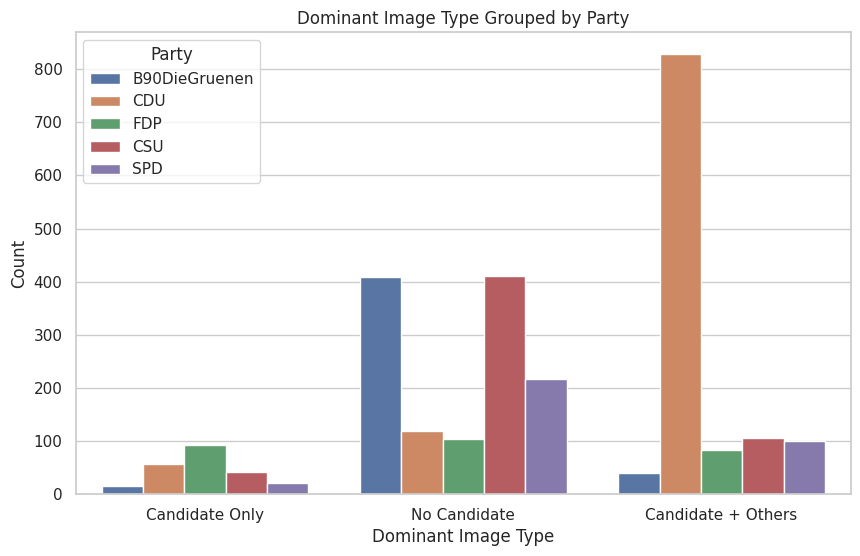

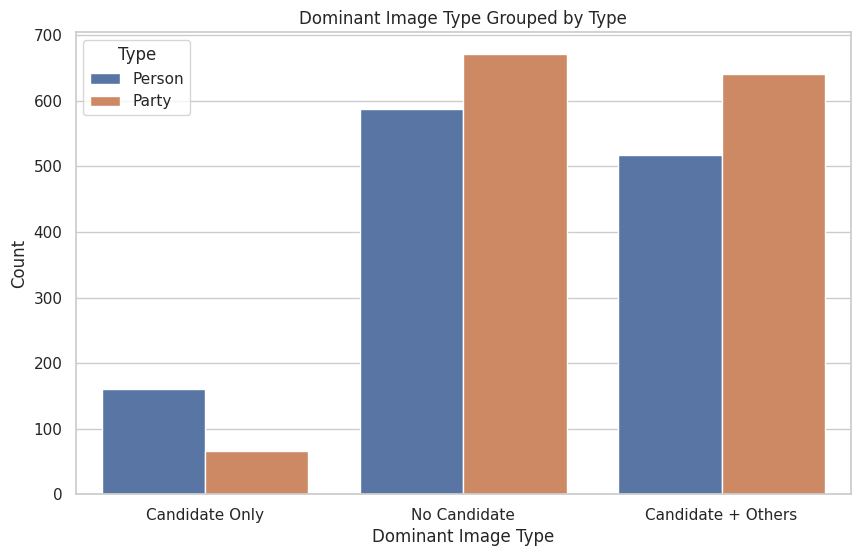

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# First plot: Group by party and plot dominant image type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dominant_image_type', hue='party')
plt.title('Dominant Image Type Grouped by Party')
plt.xlabel('Dominant Image Type')
plt.ylabel('Count')
plt.legend(title='Party')
plt.show()

# Second plot: Group by type and plot dominant image type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dominant_image_type', hue='type')
plt.title('Dominant Image Type Grouped by Type')
plt.xlabel('Dominant Image Type')
plt.ylabel('Count')
plt.legend(title='Type')
plt.show()


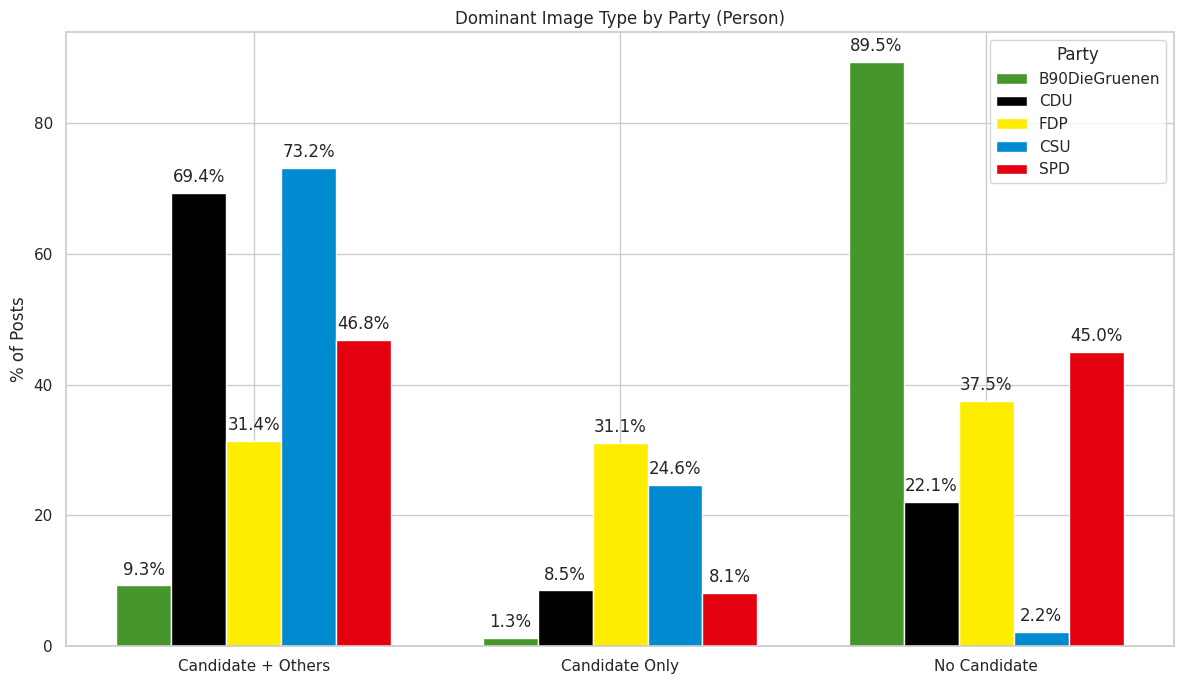

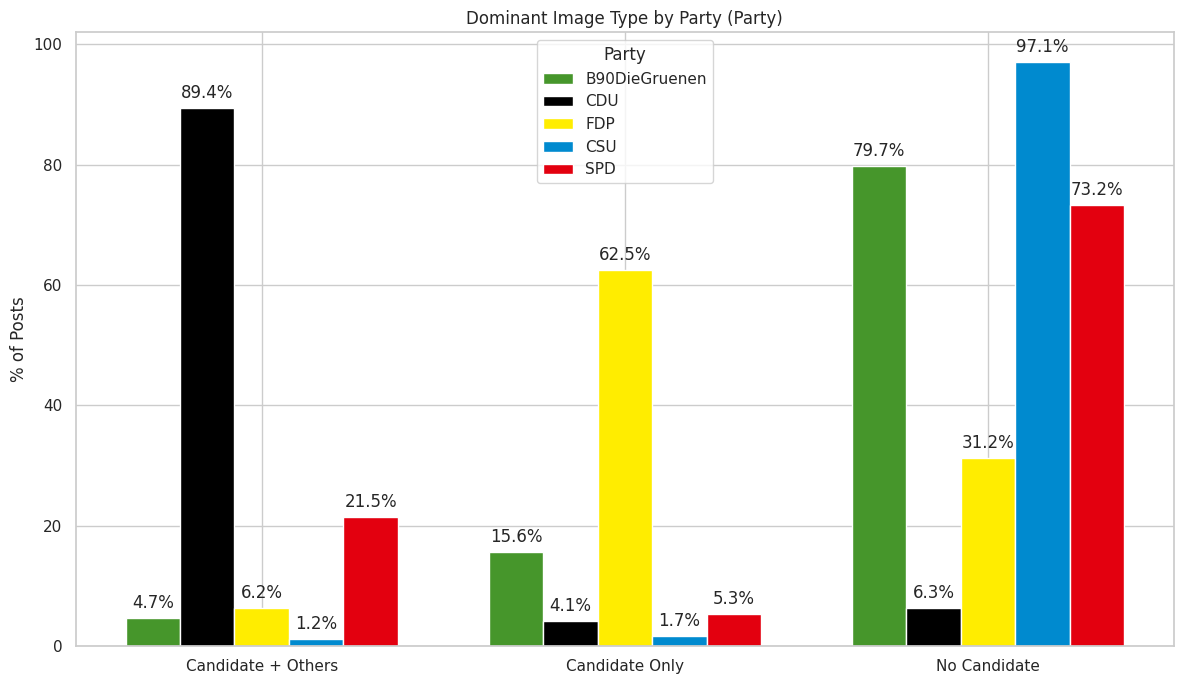

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Typical party colors
party_colors = {
    "CDU": "#000000",
    "CSU": "#008ACF",
    "SPD": "#E3000F",
    "FDP": "#FFED00",
    "B90DieGruenen": "#46962B",
}

# Function to calculate the percentage of dominant image types per party
def get_dominant_image_percentages(df, entity_type):
    percentages_dict = {label: [] for label in ['Candidate + Others', 'Candidate Only', 'No Candidate']}
    parties = df['party'].unique()

    for party in parties:
        party_df = df[(df['party'] == party) & (df['type'] == entity_type)]
        total_count = len(party_df)

        # Calculate percentage for each dominant image type
        for label in percentages_dict.keys():
            count = len(party_df[party_df['dominant_image_type'] == label])
            percentage = (count / total_count) * 100 if total_count > 0 else 0
            percentages_dict[label].append(percentage)

    return percentages_dict, parties

# Function to plot the bars for each party
def plot_dominant_image_type(df, entity_type, title):
    percentages_dict, parties = get_dominant_image_percentages(df, entity_type)

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Define bar positions and width
    bar_width = 0.15
    positions = range(len(percentages_dict.keys()))

    # Plot bars for each party
    for i, party in enumerate(parties):
        percentages = [percentages_dict[label][i] for label in percentages_dict.keys()]
        ax.bar([p + i * bar_width for p in positions], percentages, bar_width, label=party, color=party_colors.get(party, '#333333'))

    # Set labels and title
    ax.set_ylabel('% of Posts')
    ax.set_title(title)
    ax.set_xticks([p + bar_width * (len(parties) - 1) / 2 for p in positions])
    ax.set_xticklabels(percentages_dict.keys())
    ax.legend(title='Party')

    # Adding labels on top of bars
    for i, party in enumerate(parties):
        for j, label in enumerate(percentages_dict.keys()):
            percentage = percentages_dict[label][i]
            ax.text(j + i * bar_width, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom')

    # Adjust layout to avoid overlap and enhance readability
    plt.tight_layout()
    plt.show()

# Plot for 'Person' type
plot_dominant_image_type(df, "Person", "Dominant Image Type by Party (Person)")

# Plot for 'Party' type
plot_dominant_image_type(df, "Party", "Dominant Image Type by Party (Party)")


In [ ]:
# Melt the DataFrame to have one row per category
df_melted = final_df.melt(
    id_vars=['party'],
    value_vars=['Candidate + Others', 'Candidate Only', 'No Candidate'],
    var_name='Category',
    value_name='Count'
)

# Optionally, aggregate the counts by party
df_aggregated = df_melted.groupby(['party', 'Category'])['Count'].sum().reset_index()


In [ ]:
import plotly.express as px

# Create the stacked bar chart
fig = px.bar(
    df_aggregated,
    x='party',
    y='Count',
    color='Category',
    title='Candidate Categories by Party',
    labels={
        'party': 'Party',
        'Count': 'Number of Candidates',
        'Category': 'Candidate Category'
    },
    text='Count'  # Adds count labels on the bars
)

# Update layout for better aesthetics
fig.update_layout(
    barmode='stack',
    xaxis_title='Party',
    yaxis_title='Number of Candidates',
    legend_title='Category',
    template='plotly_white'
)

# Display the figure
fig.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Assuming final_df is your DataFrame
# Define the independent variables (X) and dependent variable (y)
X = final_df[['Candidate + Others', 'Candidate Only', 'No Candidate']]
y = final_df['Overperforming Score_x']

# Add a constant to the independent variables (for the intercept)
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Overperforming Score_x   R-squared:                       0.027
Model:                                OLS   Adj. R-squared:                  0.019
Method:                     Least Squares   F-statistic:                     3.223
Date:                    Fri, 20 Sep 2024   Prob (F-statistic):             0.0228
Time:                            10:09:05   Log-Likelihood:                -745.80
No. Observations:                     354   AIC:                             1500.
Df Residuals:                         350   BIC:                             1515.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

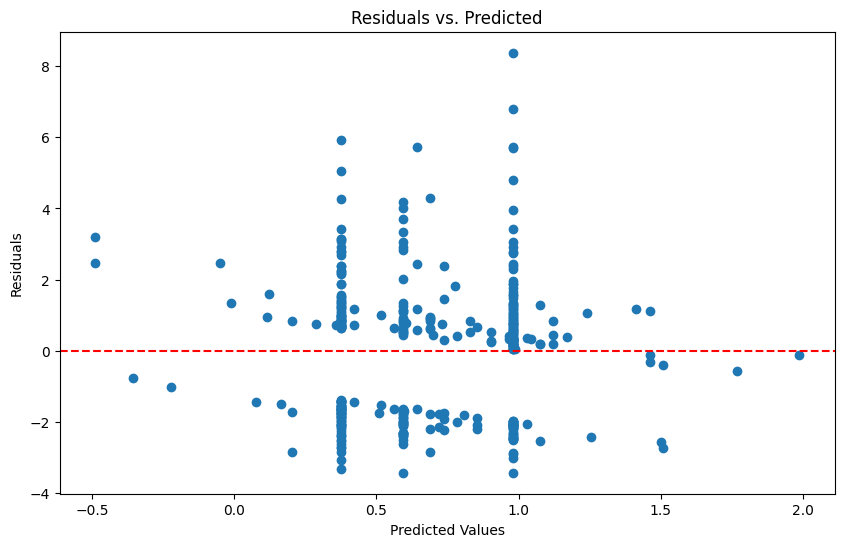

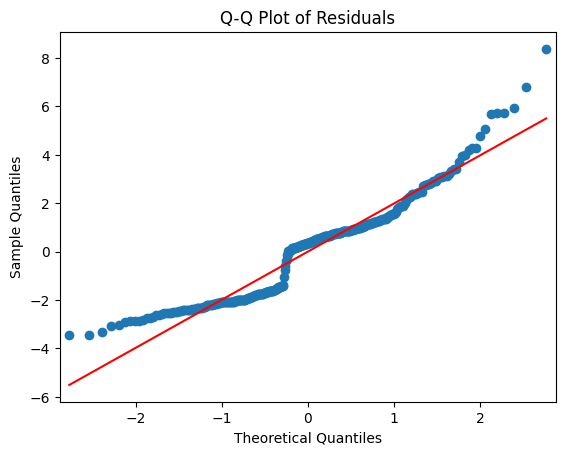

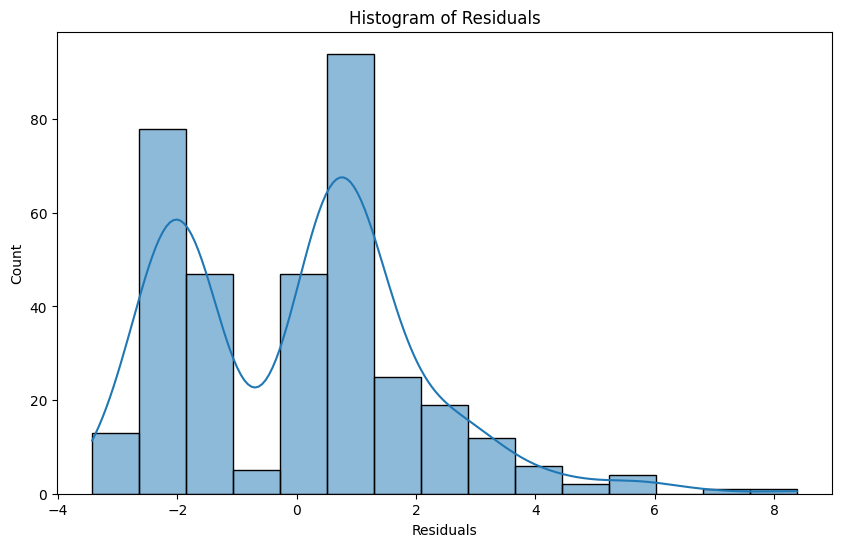

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Residuals
residuals = model.resid
predicted = model.predict(X)

# 1. Residuals vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(predicted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Q-Q plot for normality
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 3. Histogram of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.show()


In [ ]:
import statsmodels.api as sm

# Define the independent variables (X) and dependent variable (y)
X = final_df[['Candidate + Others', 'Candidate Only', 'No Candidate']]
y = final_df['Overperforming Score_x']

# Add a constant to the independent variables (for the intercept)
X = sm.add_constant(X)

# Fit the GLM with a Gaussian family and a log link (log transformation can handle non-linearity)
glm_model = sm.GLM(y, X, family=sm.families.Gaussian(sm.families.links.log())).fit()

# Print the summary of the GLM results
print(glm_model.summary())


                   Generalized Linear Model Regression Results                    
Dep. Variable:     Overperforming Score_x   No. Observations:                  354
Model:                                GLM   Df Residuals:                      350
Model Family:                    Gaussian   Df Model:                            3
Link Function:                        log   Scale:                          3.9679
Method:                              IRLS   Log-Likelihood:                -744.25
Date:                    Fri, 20 Sep 2024   Deviance:                       1388.8
Time:                            10:09:10   Pearson chi2:                 1.39e+03
No. Iterations:                        16   Pseudo R-squ. (CS):            0.03563
Covariance Type:                nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning:

The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
X_no_const = final_df[['Candidate + Others', 'Candidate Only', 'No Candidate']]
vif = pd.DataFrame()
vif["Variable"] = X_no_const.columns
vif["VIF"] = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]

print(vif)


             Variable       VIF
0  Candidate + Others  1.141145
1      Candidate Only  1.189556
2        No Candidate  1.194154


In [ ]:
# Create interaction term between 'Candidate + Others' and 'Candidate Only'
final_df['Interaction_Candidate_Others_Only'] = final_df['Candidate + Others'] * final_df['Candidate Only']

# Define the new independent variables with the interaction term
X = final_df[['Candidate + Others', 'Candidate Only', 'No Candidate', 'Interaction_Candidate_Others_Only']]
X = sm.add_constant(X)

# Fit the GLM with the interaction term
glm_model = sm.GLM(y, X, family=sm.families.Gaussian(sm.families.links.log())).fit()

# Print the summary of the new model
print(glm_model.summary())


                   Generalized Linear Model Regression Results                    
Dep. Variable:     Overperforming Score_x   No. Observations:                  354
Model:                                GLM   Df Residuals:                      349
Model Family:                    Gaussian   Df Model:                            4
Link Function:                        log   Scale:                          3.9686
Method:                              IRLS   Log-Likelihood:                -743.78
Date:                    Fri, 20 Sep 2024   Deviance:                       1385.0
Time:                            10:15:28   Pearson chi2:                 1.39e+03
No. Iterations:                        16   Pseudo R-squ. (CS):            0.03819
Covariance Type:                nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning:

The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.



In [ ]:
# Create quadratic terms
final_df['Candidate_Others_Squared'] = final_df['Candidate + Others'] ** 2
final_df['Candidate_Only_Squared'] = final_df['Candidate Only'] ** 2
final_df['No_Candidate_Squared'] = final_df['No Candidate'] ** 2

# Define the new X with quadratic terms
X = final_df[['Candidate + Others', 'Candidate Only', 'No Candidate',
              'Candidate_Others_Squared', 'Candidate_Only_Squared', 'No_Candidate_Squared']]
X = sm.add_constant(X)

# Fit the GLM with quadratic terms
glm_model = sm.GLM(y, X, family=sm.families.Gaussian(sm.families.links.log())).fit()

print(glm_model.summary())


                   Generalized Linear Model Regression Results                    
Dep. Variable:     Overperforming Score_x   No. Observations:                  354
Model:                                GLM   Df Residuals:                      347
Model Family:                    Gaussian   Df Model:                            6
Link Function:                        log   Scale:                          3.9723
Method:                              IRLS   Log-Likelihood:                -742.95
Date:                    Fri, 20 Sep 2024   Deviance:                       1378.4
Time:                            10:14:29   Pearson chi2:                 1.38e+03
No. Iterations:                       100   Pseudo R-squ. (CS):            0.04268
Covariance Type:                nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning:

The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.



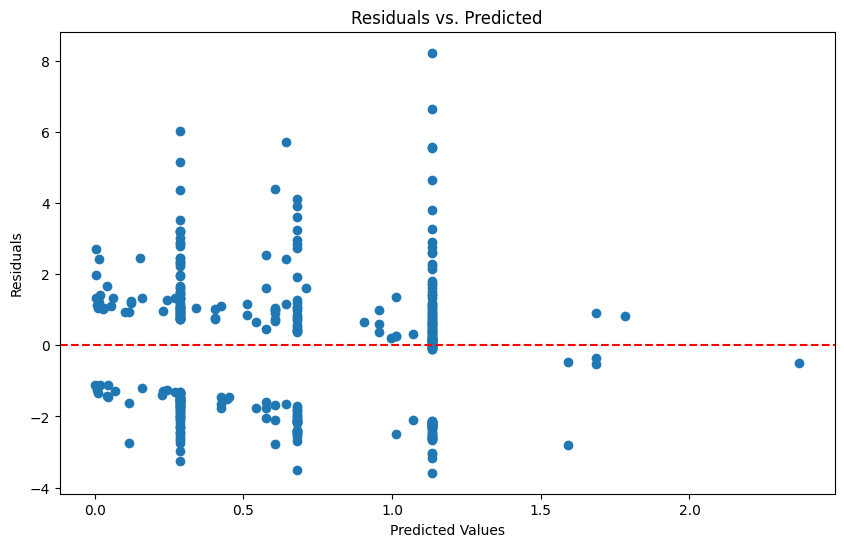

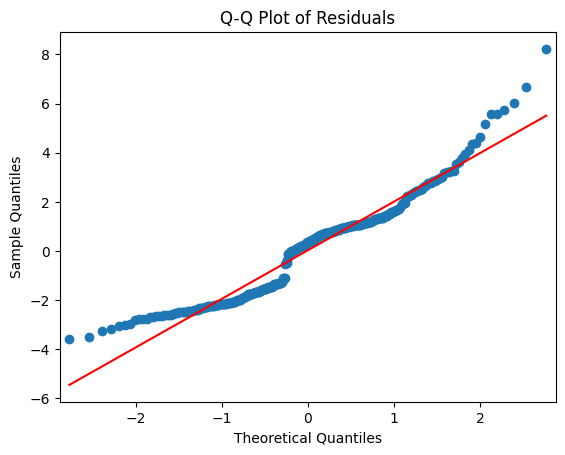

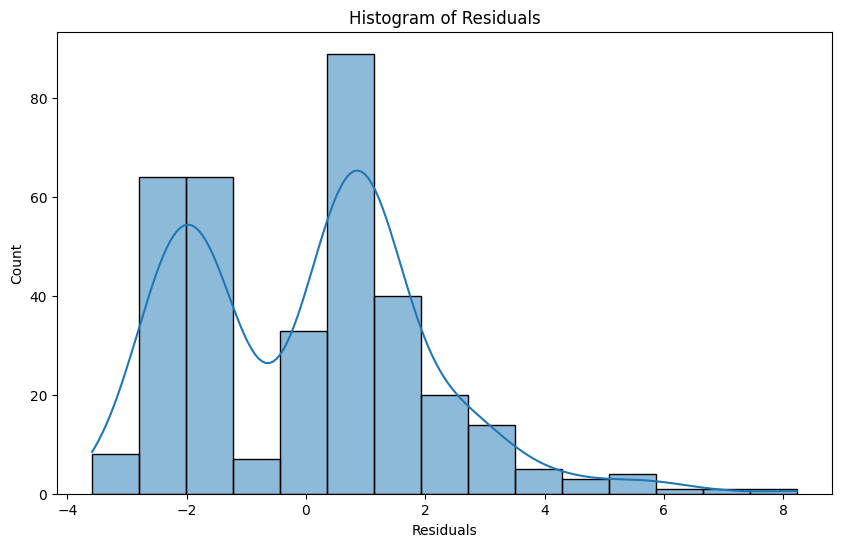

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Residuals
residuals = glm_model.resid_pearson
predicted = glm_model.predict(X)

# 1. Residuals vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(predicted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Q-Q plot for normality
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 3. Histogram of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# Define the category function
def category(row):
    if row['Candidate'] == "None":  # Fixed string comparison
        return "No Candidate"
    elif row['GPT Count'] == "1":
        return "Candidate Only"
    else:
        return "Candidate + Others"

# Assuming 'filtered' is already defined DataFrame
filtered['Group'] = filtered.apply(category, axis=1)

# Step 1: Aggregate the data
aggregated_df = filtered.groupby('shortcode').agg({
    'Overperforming Score': 'mean',  # Post level metric, use mean
    'Group': lambda x: x.mode()[0],  # Use mode
}).reset_index()

# One-hot encode 'Group' without dropping any category
encoder = OneHotEncoder(drop='first', categories=[['No Candidate', 'Candidate Only', 'Candidate + Others']], sparse_output=False)
group_encoded = encoder.fit_transform(aggregated_df[['Group']])

# Create a DataFrame from the encoded features
group_encoded_df = pd.DataFrame(group_encoded, columns=encoder.get_feature_names_out(['Group']))

# Step 3: Prepare the feature set for the model
X = pd.concat([
    aggregated_df.drop(['Overperforming Score', 'Group', 'shortcode'], axis=1).reset_index(drop=True),  # Dropping 'shortcode'
    group_encoded_df.reset_index(drop=True)
], axis=1)

# Check for NaN values in each column of X and fill with 0
X.fillna(0, inplace=True)

y = aggregated_df['Overperforming Score']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Display the coefficients
coefficients = pd.DataFrame(model.coef_, index=X.columns, columns=['Coefficient'])
print(coefficients)

                          Coefficient
Group_Candidate Only         0.934512
Group_Candidate + Others     0.306840


In [ ]:
# Retrieve regression coefficients
coefficients = pd.Series(model.coef_, index=X.columns)

In [ ]:
print(coefficients)

Group_Candidate Only        0.934512
Group_Candidate + Others    0.306840
dtype: float64


In [ ]:
import statsmodels.api as sm

# Add a constant (intercept) to the model for statsmodels regression
X_with_constant = sm.add_constant(X)

# Fit the model using statsmodels
model_sm = sm.OLS(y, X_with_constant)
results_sm = model_sm.fit()

# Get the summary of the regression, including coefficients and p-values
summary = results_sm.summary()

summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Overperforming Score   R-squared:                       0.038
Model:                              OLS   Adj. R-squared:                  0.033
Method:                   Least Squares   F-statistic:                     7.022
Date:                  Wed, 18 Sep 2024   Prob (F-statistic):            0.00102
Time:                          13:49:16   Log-Likelihood:                -745.32
No. Observations:                   355   AIC:                             1497.
Df Residuals:                       352   BIC:                             1508.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.2809      0.176      1.596      0.111      -0.065       0.627
Group_Candidate Only         0.9345      0.253      3.693      0.000       0.437       1.432
Group_Candidate + Others     0.3068      0.259      1.185      0.237      -0.202       0.816
==============================================================================
Omnibus:                       21.387   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.683
Skew:                           0.583   Prob(JB):                     7.20e-06
Kurtosis:                       3.492   Cond. No.                         3.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import pandas as pd
from scipy.stats import f_oneway

# Extract the groups for ANOVA
group_labels = filtered['Group'].unique()
groups = [filtered['Overperforming Score'][filtered['Group'] == label].values for label in group_labels]

# Perform one-way ANOVA
anova_result = f_oneway(*groups)
anova_result

F_onewayResult(statistic=7.2456353876396475, pvalue=0.0007698700367880887)

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(filtered['Overperforming Score'], filtered['Group'])
print(tukey_result)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1           group2     meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
Candidate + Others Candidate Only   0.2354 0.3416 -0.1597  0.6306  False
Candidate + Others   No Candidate  -0.3956 0.0303 -0.7613 -0.0299   True
    Candidate Only   No Candidate   -0.631 0.0007 -1.0319 -0.2302   True
------------------------------------------------------------------------
